Total rows: 18
price_moved
DOWN    9
UP      9
Name: count, dtype: int64

Logistic Regression:
Accuracy: 0.25
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00         2
          UP       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4


Random Forest:
Accuracy: 0.75
              precision    recall  f1-score   support

        DOWN       0.67      1.00      0.80         2
          UP       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



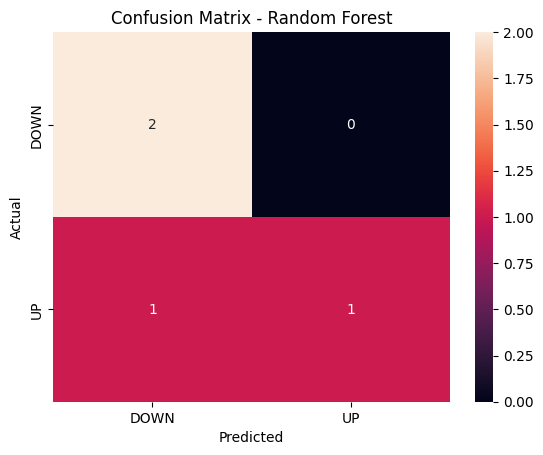

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/merged_data.csv")

# Drop the last row (NaN in next_day_return)
df = df.dropna()

print(f"Total rows: {len(df)}")
print(df['price_moved'].value_counts())

# Features and target
X = df[['avg_sentiment']]
y = df['price_moved']

# Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model 1 - Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.2f}")
print(classification_report(y_test, lr_preds))

# Model 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("\nRandom Forest:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.2f}")
print(classification_report(y_test, rf_preds))

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['DOWN','UP'], 
            yticklabels=['DOWN','UP'])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("../data/confusion_matrix.png")
plt.show()